### This first part just replicates sk's code with some comments to create the contour plot

<class 'osgeo.gdal.Dataset'>
Metadata: {'TIFFTAG_SOFTWARE': 'pix4dmapper', 'AREA_OR_POINT': 'Area'}
transform: (562472.0659, 0.017550000000000003, 0.0, 834682.21409, 0.0, -0.017550000000000003)
band= <osgeo.gdal.Band; proxy of <Swig Object of type 'GDALRasterBandShadow *' at 0x137a66f30> >
nx= 10842
ny= 10605
zmin= 360.0    zmax= 387.2865   dz= 1.364324951171875
kx= 5199    ky= 5284
calculateLine  x0=  0.0  y0=  0.0   x1=  0.1   y1=  -35.0
     a=  -350.0    b=  0.0
camera at r=35m:  z= -3.082855224609375


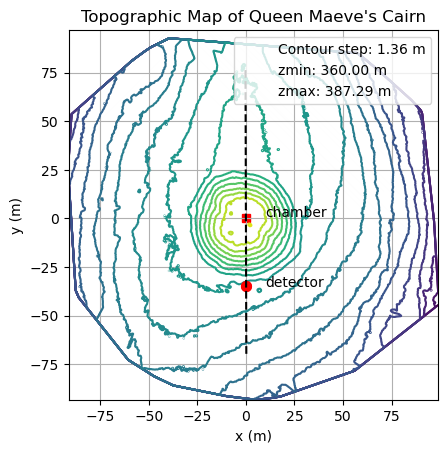

In [8]:
from osgeo import gdal  # Library for working with GeoTIFF files
import matplotlib.pyplot as plt  # Library for creating plots
from matplotlib.patches import Rectangle  # For adding rectangular shapes to plots
import numpy as np  # Library for numerical operations
from matplotlib.lines import Line2D

# Load the GeoTIFF file
infile = "/Users/odinschneider/osdir/MuonX/analysis/Knocknarea_Reprocess_dsm.tif"
dataset = gdal.Open(infile, gdal.GA_ReadOnly)  # Open the GeoTIFF in read-only mode

print(type(dataset))  # Print the type of the dataset object (should be gdal.Dataset)

# Retrieve metadata from the dataset
metadata = dataset.GetMetadata()
print("Metadata:", metadata)

# Get the GeoTransform, which defines how pixel coordinates map to geospatial coordinates
# [0] Top left X, [1] Pixel width, [2] Rotation (0 if north is up), 
# [3] Top left Y, [4] Rotation (0 if north is up), [5] Pixel height (negative for north-up orientation)
transform = dataset.GetGeoTransform()
print("transform:", transform)

# Access the first raster band (GeoTIFF bands are indexed starting at 1)
band = dataset.GetRasterBand(1)
print("band=", band)

# Read the raster band data as a NumPy array
arr = band.ReadAsArray()

# Get the number of rows (ny) and columns (nx) in the raster
ny, nx = arr.shape
print("nx=", nx)
print("ny=", ny)

# Normalize the elevation values for visualization
Z0 = 377.5  # Reference elevation level
arr2 = np.clip(arr, 360.0, 400.0)  # Clip elevation values between 360 and 400

# Define the number of contour levels
nc = 20

# Compute the scale of the raster (distance per pixel in X direction)
scale = transform[1]

# Generate coordinate ranges for X and Y based on pixel indices and scaling
amin = -scale * 5000.0
a = np.arange(amin, 500.0, scale)
x = a[:nx] - 3.5
y = -(a[:ny] - 5.0)

# Compute minimum and maximum values for contours
zmin = np.amin(arr2)
zmax = np.amax(arr2)
dz = (zmax - zmin) / nc  # Contour step size
print("zmin=", zmin, "   zmax=", zmax, "  dz=", dz)

# Create a title for the contour plot
s = str(round(dz, 2))
s_title = f"contour step {s} m,  zmin {round(zmin, 2)}  zmax {round(zmax, 2)}"

# Identify indices where X and Y cross the origin
kx = 0
ky = 0
for k in np.arange(0, nx - 1000, 1):
    if x[k] * x[k + 1] < 0.0:
        kx = k
    if y[k] * y[k + 1] < 0.0:
        ky = k

print("kx=", kx, "   ky=", ky)

# Define positions for specific points
xpoint5 = np.array([x[kx], x[10738]])
ypoint5 = np.array([y[ky], y[6603]])

# Define camera position for the dashed line
xcam = np.array([0.1, 0.1])
ycam = np.array([-35.0, -35.0])

# Function to calculate a line (camera view) and associated values
def calculateLine(xx, yy, arr2, x0, y0, x1, y1):
    # Line equation: y = ax + b
    aa = (y1 - y0) / (x1 - x0)
    bb = y0 - aa * x0
    print("calculateLine  x0= ", x0, " y0= ", y0, "  x1= ", x1, "  y1= ", y1)
    print("     a= ", aa, "   b= ", bb)

    xTemp, yTemp, zTemp = np.ones(len(yy)), np.ones(len(yy)), np.ones(len(yy))
    ct = -1  # Counter for points
    startScan = 0  # Used to ensure we cross the line before capturing points

    # Loop over grid points and evaluate the line
    for ctX, xa in enumerate(xx):
        if xa < -80.0 or xa > 80.0:
            continue
        for ctY, ya in enumerate(yy):
            if ya < -80.0 or ya > 80.0:
                continue
            if ctX >= len(yy) or ctY >= len(yy):
                continue
            dy = ya - (aa * xa + bb)
            if dy > 0.0:
                startScan = 1
            if dy < 0.0 and startScan == 1:
                ct += 1
                xTemp[ct], yTemp[ct], zTemp[ct] = xa, ya, arr2[ctY, ctX]
                break

    # Extract and calculate values along the line
    xL_ = xTemp[:ct]
    yL_ = yTemp[:ct]
    zL_ = zTemp[:ct]
    rL_ = np.sqrt(xL_ ** 2 + yL_ ** 2) * np.sign(xL_)

    # Calculate elevation at a specific distance
    r35, z35 = 35.0, 0.0
    for ct, r in enumerate(rL_):
        if r > r35:
            z35 = zL_[ct] - Z0
            break

    print("camera at r=35m:  z=", z35)
    return xL_, yL_, zL_, rL_, r35, z35

# Calculate line based on camera position
xL3, yL3, zL3, rL3, r35, z35 = calculateLine(x, y, arr2, 0.0, 0.0, xcam[0], ycam[0])

# Create the contour plot
fig1 = plt.figure(1)
ax1 = fig1.add_subplot(111)
ax1.contour(x, y, arr2, nc)  # Generate contour lines
ax1.plot(xcam, ycam, 'o-', color='r', markersize=7)  # Mark the camera position
ax1.plot(xL3, yL3, '--', color='k')  # Plot the dashed line for the camera view
ax1.add_patch(Rectangle((-2.0, -2.0), 4.0, 4.0, angle=0.0, color="red", fill=True))  # Add a rectangular marker

# Create legend with contour step, zmin, and zmax
legend_elements = [
    Line2D([0], [0], linestyle="none", label=f"Contour step: {dz:.2f} m"),
    Line2D([0], [0], linestyle="none", label=f"zmin: {zmin:.2f} m"),
    Line2D([0], [0], linestyle="none", label=f"zmax: {zmax:.2f} m")
]
ax1.legend(handles=legend_elements, loc="upper right", frameon=True)

# Add labels, grid, and axis settings
plt.grid(True)
plt.title("Topographic Map of Queen Maeve's Cairn")
ax1.text(10.0, 1.0, 'chamber', color='k')
ax1.text(10.0, -35.0, 'detector', color='k')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis('square')

# Show the plot
plt.show()


### Now to create the stl file

xred=[-91.25   -91.0745 -90.899  ...  98.641   98.8165  98.992 ]
Terrain STL file saved as 'terrain.stl'


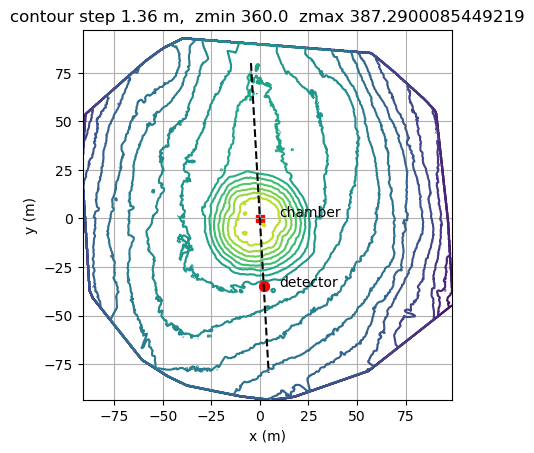

In [16]:
from stl import mesh

reduction = 10
xred = x[::reduction]
print(f"xred={xred}")
yred = y[::reduction]
zred = arr2[::reduction, ::reduction]

fig1 = plt.figure(1)
ax1 = fig1.add_subplot(111)
ax1.contour(xred, yred, zred, nc)  # Generate contour lines
ax1.plot(xcam, ycam, 'o-', color='r', markersize=7)  # Mark the camera position
ax1.plot(xL3, yL3, '--', color='k')  # Plot the dashed line for the camera view
ax1.add_patch(Rectangle((-2.0, -2.0), 4.0, 4.0, angle=0.0, color="red", fill=True))  # Add a rectangular marker

# Add labels, grid, and axis settings
plt.grid(True)
plt.title(s_title)
ax1.text(10.0, 1.0, 'chamber', color='k')
ax1.text(10.0, -35.0, 'detector', color='k')
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis('square')

vertices = []
for index_x, xx in enumerate(xred):
    for index_y, yy in enumerate(yred):
        vertices.append([xx, yy, zred[index_y, index_x]])

vertices = np.array(vertices)
# print(vertices[0:20])


# Dimensions of the grid
ny, nx = zred.shape  # Assuming zred is the same shape as the grid

# Array to store faces
faces = []

# Loop through each grid cell
for i in range(ny - 1):  # Loop through rows
    for j in range(nx - 1):  # Loop through columns
        # Indices of the four corners of the grid cell
        v0 = i * nx + j          # Top-left vertex
        v1 = i * nx + (j + 1)    # Top-right vertex
        v2 = (i + 1) * nx + j    # Bottom-left vertex
        v3 = (i + 1) * nx + (j + 1)  # Bottom-right vertex

        # Define two triangles for the cell
        faces.append([v0, v1, v2])  # Triangle 1
        faces.append([v1, v3, v2])  # Triangle 2

# Convert the faces list to a numpy array
faces = np.array(faces)
# print(faces[0:20])

# Create the mesh object
terrain = mesh.Mesh(np.zeros(faces.shape[0], dtype=mesh.Mesh.dtype))

# Assign the vertices to the mesh
for i, f in enumerate(faces):
    for j in range(3):
        terrain.vectors[i][j] = vertices[f[j], :]  # Use the vertex indices from faces

# Save the mesh to a file
terrain.save('/Users/odinschneider/osdir/MuonX/analysis/terrain.stl')

print("Terrain STL file saved as 'terrain.stl'")

### Next we create the gdml file from a .step file. Use Fusion360 to create/convert .stl to .step

In Fusion360, open the .stl file and export it as .step for this next part

In [3]:
import pyg4ometry
reg = pyg4ometry.geant4.registry()
r = pyg4ometry.stl.Reader("/Users/odinschneider/osdir/MuonX/analysis/terrain.stl", reg)
s = r.getSolid()
# r.shapeTool.Dump()
copper = pyg4ometry.geant4.MaterialPredefined("G4_Cu", reg)
l = pyg4ometry.geant4.LogicalVolume(s, copper, "terrain", reg)
v = pyg4ometry.visualisation.VtkViewerColouredMaterial()
v.addLogicalVolume(l)
# v.view()

Welcome to JupyROOT 6.30/04


AttributeError: module 'pyg4ometry.geant4' has no attribute 'terrain_registry'

In [24]:
import pyg4ometry

# Load and convert the terrain
terrain_r = pyg4ometry.pyoce.Reader("/Users/odinschneider/osdir/MuonX/analysis/terrain_no_mound.step")
terrain_r.shapeTool.Dump()
terrain_reg = pyg4ometry.convert.oce2Geant4(terrain_r.shapeTool, "terrain_no_mound v1")

# Load and convert the mound
mound_r = pyg4ometry.pyoce.Reader("/Users/odinschneider/osdir/MuonX/analysis/mound.step")
mound_r.shapeTool.Dump()
mound_reg = pyg4ometry.convert.oce2Geant4(mound_r.shapeTool, "mound v0")



# Name needs to be changed to avoid crashing in geant4
old_name_mound = "mound v0"
new_name_mound = "mound_v0"

# Update the logical volume dictionary if it exists
if old_name_mound in mound_reg.logicalVolumeDict:
    lv = mound_reg.logicalVolumeDict.pop(old_name_mound)
    lv.name = new_name_mound
    mound_reg.logicalVolumeDict[new_name_mound] = lv

# Update the solid dictionary if the solid was registered under the same name
if old_name_mound in mound_reg.solidDict:
    solid = mound_reg.solidDict.pop(old_name_mound)
    solid.name = new_name_mound
    mound_reg.solidDict[new_name_mound] = solid


old_name_terrain = "terrain_no_mound v1"
new_name_terrain = "terrain_no_mound_v1"

# Update the logical volume dictionary if it exists
if old_name_terrain in terrain_reg.logicalVolumeDict:
    lv = terrain_reg.logicalVolumeDict.pop(old_name_terrain)
    lv.name = new_name_terrain
    terrain_reg.logicalVolumeDict[new_name_terrain] = lv

# Update the solid dictionary if the solid was registered under the same name
if old_name_terrain in terrain_reg.solidDict:
    solid = terrain_reg.solidDict.pop(old_name_terrain)
    solid.name = new_name_terrain
    terrain_reg.solidDict[new_name_terrain] = solid



# Move solids from mound_reg to terrain_reg, skipping key "wl" if present
for k, v in mound_reg.solidDict.items():
    if k != "wl":
        terrain_reg.solidDict[k] = v

# Move logical volumes from mound_reg to terrain_reg, skipping key "wl"
for k, v in mound_reg.logicalVolumeDict.items():
    if k != "wl":
        terrain_reg.logicalVolumeDict[k] = v

# For materials, if there's no undesired key, copy all
for k, v in mound_reg.materialDict.items():
    terrain_reg.materialDict[k] = v




# print("Terrain combined stuff: ", list(terrain_reg.logicalVolumeDict.values()))

# Extract terrain and mound logical volumes
terrain_lv = list(terrain_reg.logicalVolumeDict.values())[1]  # second volume is terrain
mound_lv = list(terrain_reg.logicalVolumeDict.values())[2]  # third volume is mound


# Updating names such that solids and logical volumes have different names

# For the mound:
old_lv_name_mound = "mound_v0"  # the name after NCName fix (solid and lv share it now)
new_lv_name_mound = "mound_v0_lv"  # new name for the logical volume

if old_lv_name_mound in terrain_reg.logicalVolumeDict:
    lv = terrain_reg.logicalVolumeDict.pop(old_lv_name_mound)
    lv.name = new_lv_name_mound
    terrain_reg.logicalVolumeDict[new_lv_name_mound] = lv

# For the terrain:
old_lv_name_terrain = "terrain_no_mound_v1"  # the name after NCName fix
new_lv_name_terrain = "terrain_no_mound_v1_lv"  # new name for the logical volume

if old_lv_name_terrain in terrain_reg.logicalVolumeDict:
    lv = terrain_reg.logicalVolumeDict.pop(old_lv_name_terrain)
    lv.name = new_lv_name_terrain
    terrain_reg.logicalVolumeDict[new_lv_name_terrain] = lv



# Define elements in terrain_reg
elO = pyg4ometry.geant4.ElementSimple("Oxygen", "O", 8, 16.00, terrain_reg)
elSi = pyg4ometry.geant4.ElementSimple("Silicon", "Si", 14, 28.0855, terrain_reg)
elAl = pyg4ometry.geant4.ElementSimple("Aluminium", "Al", 13, 26.981539, terrain_reg)
elFe = pyg4ometry.geant4.ElementSimple("Iron", "Fe", 26, 55.845, terrain_reg)
elCa = pyg4ometry.geant4.ElementSimple("Calcium", "Ca", 20, 40.078, terrain_reg)
elNa = pyg4ometry.geant4.ElementSimple("Sodium", "Na", 11, 22.9898, terrain_reg)
elK = pyg4ometry.geant4.ElementSimple("Potassium", "K", 19, 39.0983, terrain_reg)
elMg = pyg4ometry.geant4.ElementSimple("Magnesium", "Mg", 12, 24.305, terrain_reg)


# Define elements for air (Has to be done manually otherwise the material won't be written in gdml file if use predefined)
elN = pyg4ometry.geant4.ElementSimple("Nitrogen", "N", 7, 14.007, terrain_reg)
# elO = pyg4ometry.geant4.ElementSimple("Oxygen", "O", 8, 15.999, terrain_reg)  # Already defined above

# Create an air material (density in g/cm3, using a typical value for air at STP)
# Here we assume two components. The mass fractions are approximate.
air = pyg4ometry.geant4.MaterialCompound("Air", 0.001205, 2, terrain_reg)
air.add_element_massfraction(elN, 0.70)
air.add_element_massfraction(elO, 0.30)

# Use the newly created air material for your world volume
world_material = air


# Define terrain and mound materials
density_rock1 = 2680.0
num_components = 8
rock1 = pyg4ometry.geant4.MaterialCompound("Rock1", density_rock1, num_components, terrain_reg)
rock1.add_element_massfraction(elO, (46.60 + 1.41) / 100)
rock1.add_element_massfraction(elSi, 27.72 / 100)
rock1.add_element_massfraction(elAl, 8.13 / 100)
rock1.add_element_massfraction(elFe, 5.00 / 100)
rock1.add_element_massfraction(elCa, 3.63 / 100)
rock1.add_element_massfraction(elNa, 2.83 / 100)
rock1.add_element_massfraction(elK, 2.59 / 100)
rock1.add_element_massfraction(elMg, 2.09 / 100)

density_rock2 = density_rock1 * 0.9
rock2 = pyg4ometry.geant4.MaterialCompound("Rock2", density_rock2, num_components, terrain_reg)
rock2.add_element_massfraction(elO, (46.60 + 1.41) / 100)
rock2.add_element_massfraction(elSi, 27.72 / 100)
rock2.add_element_massfraction(elAl, 8.13 / 100)
rock2.add_element_massfraction(elFe, 5.00 / 100)
rock2.add_element_massfraction(elCa, 3.63 / 100)
rock2.add_element_massfraction(elNa, 2.83 / 100)
rock2.add_element_massfraction(elK, 2.59 / 100)
rock2.add_element_massfraction(elMg, 2.09 / 100)



# Define a larger world volume
world_solid = pyg4ometry.geant4.solid.Box("WorldBox", 300000, 300000, 300000, terrain_reg)  # Adjust size as needed
world_lv = pyg4ometry.geant4.LogicalVolume(world_solid, world_material, "world_lv", terrain_reg)

# Set the world volume in terrain_reg
terrain_reg.setWorld(world_lv.name)


# Assign materials to logical volumes
terrain_lv.material = rock1
mound_lv.material = rock2

# Place terrain in world volume
terrain_pv = pyg4ometry.geant4.PhysicalVolume(
    [0, 0, 0], [0, 0, 0], terrain_lv, "terrain_pv", world_lv, terrain_reg
)

# Place mound on top of terrain (adjust Z based on terrain height)
terrain_height = 0  # Adjust based on actual terrain height (guards against geometry overlap)
mound_pv = pyg4ometry.geant4.PhysicalVolume(
    [0, 0, 0], [0, 0, terrain_height], mound_lv, "mound_pv", world_lv, terrain_reg
)

print("Terrain combined updated stuff: ", list(terrain_reg.logicalVolumeDict.values()))


# Write to GDML
w = pyg4ometry.gdml.Writer()
w.addDetector(terrain_reg)
w.write('/Users/odinschneider/osdir/MuonX/analysis/terrain.gdml')

print("GDML file written successfully!")

	XCAFDoc_ShapeTool	Trans. 0; Valid;	ID = efd212ee-6dfd-11d4-b9c8-0060b0ee281b

PART SOLID 0:1:1:1 "terrain_no_mound v1" 


Free Shapes: 1
PART SOLID  0:1:1:1 "terrain_no_mound v1" 
	XCAFDoc_ShapeTool	Trans. 0; Valid;	ID = efd212ee-6dfd-11d4-b9c8-0060b0ee281b

PART SOLID 0:1:1:1 "mound v0" 


Free Shapes: 1
PART SOLID  0:1:1:1 "mound v0" 
Terrain combined updated stuff:  [Logical volume : wl Box : name=worldSolid x=299999.7950366297 y=299999.99093150604 z=54256.2266907552 G4_Galactic, Logical volume : mound_v0_lv TessellatedSolid TessellatedSolid Rock2, Logical volume : terrain_no_mound_v1_lv TessellatedSolid TessellatedSolid Rock1, Logical volume : world_lv Box : name=WorldBox x=300000.0 y=300000.0 z=300000.0 Air]
GDML file written successfully!


# Turn the .gdml file into a header file that is used in the sim/include folder of the simulation

In [ ]:
import xml.etree.ElementTree as ET

# Path to your GDML file (update this path as needed)
gdml_file = "terrain.gdml"

# Parse the GDML file
tree = ET.parse(gdml_file)
root = tree.getroot()

# ----------------------------------
# Extract vertex definitions from <define>
# ----------------------------------
vertices = {}
# Look for <position> elements under the <define> section.
for pos in root.findall(".//define/position"):
    name = pos.attrib["name"]
    x = float(pos.attrib["x"])
    y = float(pos.attrib["y"])
    z = float(pos.attrib["z"]) + 2000   # This adds 2m in z direction so that the chamber at 0,0,0 is placed better
    unit = pos.attrib.get("unit", "mm")  # Default unit is mm if not specified
    # Convert units (assume GDML uses mm, cm, or m)
    unit_scale = {"mm": 1, "cm": 10, "m": 1000}
    scale = unit_scale.get(unit, 1)
    vertices[name] = (x * scale, y * scale, z * scale)

# ----------------------------------
# Extract tessellated solids from <solids>
# ----------------------------------
tess_solids = {}
# Look for each <tessellated> element under <solids>
for tess in root.findall(".//solids/tessellated"):
    solid_name = tess.attrib["name"]
    facets = []
    for tri in tess.findall("triangular"):
        v1 = tri.attrib["vertex1"]
        v2 = tri.attrib["vertex2"]
        v3 = tri.attrib["vertex3"]
        facets.append((v1, v2, v3))
    tess_solids[solid_name] = facets

# ----------------------------------
# Generate TessellatedVertices.hh
# ----------------------------------
vertices_filename = "TessellatedVertices.hh"
with open(vertices_filename, "w") as f:
    f.write("#ifndef TESSELLATED_VERTICES_HH\n")
    f.write("#define TESSELLATED_VERTICES_HH\n\n")
    f.write('#include "G4ThreeVector.hh"\n')
    f.write('#include "G4SystemOfUnits.hh"\n\n')
    f.write("// Vertex definitions extracted from GDML\n")
    for name, (x, y, z) in vertices.items():
        f.write(f"const G4ThreeVector {name}({x:.6f}*mm, {y:.6f}*mm, {z:.6f}*mm);\n")
    f.write("\n#endif // TESSELLATED_VERTICES_HH\n")

# ----------------------------------
# Generate TessellatedGeometry.hh
# ----------------------------------
geometry_filename = "TessellatedGeometry.hh"
with open(geometry_filename, "w") as f:
    f.write("#ifndef TESSELLATED_GEOMETRY_HH\n")
    f.write("#define TESSELLATED_GEOMETRY_HH\n\n")
    f.write('#include "G4TessellatedSolid.hh"\n')
    f.write('#include "G4TriangularFacet.hh"\n')
    f.write('#include "TessellatedVertices.hh"\n')
    f.write('#include "G4SystemOfUnits.hh"\n\n')
    f.write("/*\n")
    f.write("  This header declares an inline function that creates tessellated solids\n")
    f.write("  from the GDML facet definitions. It creates the following solids:\n")
    for solid in tess_solids:
        f.write(f"    - {solid}\n")
    f.write("*/\n\n")
    # The inline function assigns the solid whose name contains "terrain" to terrainSolid
    # and the one whose name contains "mound" to moundSolid.
    f.write("inline void DefineTessellatedSolids(G4TessellatedSolid*& terrainSolid, G4TessellatedSolid*& moundSolid) {\n")
    for solid_name, facets in tess_solids.items():
        if "terrain" in solid_name:
            f.write(f'    terrainSolid = new G4TessellatedSolid("{solid_name}");\n')
            for (v1, v2, v3) in facets:
                f.write(f'    terrainSolid->AddFacet(new G4TriangularFacet({v1}, {v2}, {v3}, ABSOLUTE));\n')
            f.write("    terrainSolid->SetSolidClosed(true);\n\n")
        elif "mound" in solid_name:
            f.write(f'    moundSolid = new G4TessellatedSolid("{solid_name}");\n')
            for (v1, v2, v3) in facets:
                f.write(f'    moundSolid->AddFacet(new G4TriangularFacet({v1}, {v2}, {v3}, ABSOLUTE));\n')
            f.write("    moundSolid->SetSolidClosed(true);\n\n")
        else:
            # If there are other tessellated solids, you can handle them here.
            f.write(f'    // Solid "{solid_name}" not assigned to a parameter\n');
    f.write("}\n\n")
    f.write("#endif // TESSELLATED_GEOMETRY_HH\n")

print("Generated header files:", vertices_filename, "and", geometry_filename)
